### Setup

- Difffusers

In [1]:
# !git clone https://github.com/huggingface/diffusers.git
# %cd diffusers
# !pip install .
# %cd ..

- Peft

In [2]:
# !git clone https://github.com/huggingface/peft.git
# %cd peft
# !pip install .
# %cd ..

- Library

In [15]:
import torch, transformers, datasets, diffusers, peft
import random
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import os
import json
from datasets import Dataset, DatasetDict
from tqdm import tqdm
from PIL import Image
from IPython.display import display

import torch
import torch.nn.functional as F
from torchvision import transforms
import transformers, datasets, diffusers
from transformers import CLIPTextModel, CLIPTokenizer
from huggingface_hub import login

from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline, StableDiffusionPipeline
from diffusers.optimization import get_scheduler
from diffusers.utils import convert_state_dict_to_diffusers
from diffusers.training_utils import cast_training_params

from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device : ',device)   
print('package version : ',torch.__version__, transformers.__version__, datasets.__version__, diffusers.__version__, peft.__version__)

# BASIC CONFIG
CURRENT_TIME = datetime.now().strftime("%Y%m%d_%H%M%S")

# TRAIN CONFIG
PRE_TRAINED_MODEL_NAME="stablediffusionapi/deliberate-v2"
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 4
EPOCHS = 2
LEARNING_RATE = 1e-04

# PATH
CONFIG_PATH = '../config.json'
IMAGE_FOLDER = '../Data/Total/Total_Image'
LABEL_FOLDER = '../Data/Total/Total_CLIP_Summarize'
IMAGE_FILE = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')])[:100]
LABEL_FILE = sorted([f for f in os.listdir(LABEL_FOLDER) if f.endswith('.json')])[:100]
SAVE_MODEL_PATH = f"../Experiment/model/FIGMA_{CURRENT_TIME}"
SAVE_WEIGHTS_PATH = f"../Experiment/model_weights/FIGMA_weights_{CURRENT_TIME}"

# HUGGINGFACE
with open(CONFIG_PATH,'r') as f:
    config = json.load(f)
HUGGING_FACE_TOKEN = config.get("HUGGING_FACE_TOKEN")
login(HUGGING_FACE_TOKEN)

device :  cuda
package version :  2.4.1+cu124 4.46.2 3.0.1 0.33.0.dev0 0.7.0


### Load Data

In [2]:
data = []
for image_file, label_file in zip(IMAGE_FILE, LABEL_FILE):
    image_path = os.path.join(IMAGE_FOLDER, image_file)
    label_path = os.path.join(LABEL_FOLDER, label_file)
    # 이미지 파일 열기
    with open(image_path, 'rb') as image:
        image_data = Image.open(image)
        image_data = image_data.convert('RGB') # RGB로 변환
        
    # 라벨 파일 열기
    with open(label_path, 'r') as label:
        label_data = json.load(label)
        
    # 이미지와 라벨 데이터 묶기
    data.append({
        'image':image_data,
        'text':label_data
    })
    
# Dataset으로 변환
dataset = Dataset.from_dict({
    'image': [item['image'] for item in data],
    'text': [item['text']['summary'] for item in data]
})
# DatasetDict 생성
dataset = DatasetDict({
    'train': dataset
})
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 20
    })
})

### Load Model

In [3]:
noise_scheduler = DDPMScheduler.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="scheduler"
)
tokenizer = CLIPTokenizer.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="tokenizer"
)
text_encoder = CLIPTextModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="text_encoder"
)
vae = AutoencoderKL.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="vae"
)
unet = UNet2DConditionModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="unet"
)
# 모델에 입력되는 최대 토큰 길이
tokenizer.model_max_length

77

### Preprocess Data

In [4]:
# 주어진 데이터 샘플에서 text 컬럼을 토크나이징하여 토큰 ID tensor를 반환하는 함수.
def tokenize_captions(examples, caption_column='text', is_train=True):
    captions = []
    for caption in examples[caption_column]:
        # 캡션이 하나인 경우
        if isinstance(caption, str):
            captions.append(caption)
        # 캡션이 하나 이상인 경우 아무거나 하나 선택
        elif isinstance(caption, (list, np.ndarray)):
            # take a random caption if there are multiple
            captions.append(random.choice(caption) if is_train else caption[0])
        else:
            raise ValueError(
                f"Caption column `{caption_column}` should contain either strings or lists of strings."
            )
    inputs = tokenizer(
        captions, max_length=tokenizer.model_max_length, padding="max_length", truncation=True, return_tensors="pt"
    )

    return inputs.input_ids

# 이미지 데이터를 학습용으로 전처리하는 변환 파이프라인
train_transforms = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(IMG_SIZE) if True else transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip() if True else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]), # (0,1)->(-1,1)
    ]
)

# 이미지 데이터를 RGB로 변환 후 전처리하고, text 컬럼을 토크나이징하여 학습 데이터셋을 구성하는 함수.
def preprocess_train(examples, image_column='image'):
    images = [image.convert("RGB") for image in examples[image_column]]
    # 이미지 전처리
    examples["pixel_values"] = [train_transforms(image) for image in images]
    # 텍스트 전처리
    examples["input_ids"] = tokenize_captions(examples)
    return examples

In [5]:
# 배치 단위로 이미지와 토큰 ID를 스택하여 PyTorch 텐서 형태로 변환하는 함수.
def collate_fn(examples):
    # (C, H, W), ..., (C, H, W) -> stack -> (N, C, H, W): N으로 스택
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    # tensor.contiguous()와 동일
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
    # {(77,), ..., (77,)}_N개 -> stack -> (N, 77)
    input_ids = torch.stack([example["input_ids"] for example in examples])

    return {"pixel_values": pixel_values, "input_ids": input_ids}

# 데이터 실시간 변환 적용
train_dataset = dataset["train"].with_transform(preprocess_train)
# 데이터 로더 생성
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

In [6]:
# 데이터 로더 테스트
train_dataloader_iter = iter(train_dataloader)
mini_batch = next(train_dataloader_iter)

# 이미지 데이터, 캡션 데이터
print('Image Data : ', mini_batch['pixel_values'].shape)
print('Caption Data : ', mini_batch['input_ids'].shape)

# 참고 text_encoder의 출력
# BaseModelOutputWithPooling 이 되돌려지는데 [0]이 last_hidden_state
# 트랜스포머 인코더의 마지막 히든층 츨력이므로 크기는 (batch size, time step, model dim)
print('Text Encoder : ', text_encoder(mini_batch['input_ids'])[0].shape)

Image Data :  torch.Size([4, 3, 512, 512])
Caption Data :  torch.Size([4, 77])
Text Encoder :  torch.Size([4, 77, 768])


### Train Setting

In [7]:
# FP16을 AMP으로 적용하기 위한 세팅
weight_dtype = torch.float16 
# unet, vae와 텍스트 인코더는 미세조정에서 학습되지 않음
unet.requires_grad_(False)
vae.requires_grad_(False)
text_encoder.requires_grad_(False);

# LoRA Adapter 준비
LORA_RANK = 4
# Freeze the unet parameters before adding adapters
for param in unet.parameters():
    param.requires_grad_(False)
unet_lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)
# GPU로 이동
text_encoder.to(device);
vae.to(device);
unet.to(device);
unet.add_adapter(unet_lora_config)

# Cast the trainable parameters to float32
if weight_dtype == torch.float16:
    # only upcast trainable parameters (LoRA) into fp32
    cast_training_params(unet, dtype=torch.float32)

lora_layers = filter(lambda p: p.requires_grad, unet.parameters())

# Optimizer 설정
optimizer = torch.optim.AdamW(
        lora_layers,
        lr=LEARNING_RATE,
    )
# Scheduler 설정
lr_scheduler = get_scheduler(
        'linear',
        optimizer=optimizer,
        num_warmup_steps=500,
        num_training_steps=EPOCHS * len(train_dataloader)
    )

### Train Loop

In [8]:
use_amp = True
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
prediction_type = None # 'epsilon'  or 'v_prediction'

train_losses = []

for epoch in range(EPOCHS):
    for step, batch in enumerate(tqdm(train_dataloader)):
        with torch.autocast(device_type=device, dtype=weight_dtype, enabled=use_amp):
            # Convert images to latent space
            latents = vae.encode(
                batch["pixel_values"].to(device)
            ).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

            # Sample noise that we'll add to the latents
            noise = torch.randn_like(latents)

            bsz = latents.shape[0]
            # Sample a random timestep for each image
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device)
            timesteps = timesteps.long()

            # Add noise to the latents according to the noise magnitude at each timestep
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # Get the text embedding for conditioning, [0]: last_hidden_state
            encoder_hidden_states = text_encoder(batch["input_ids"].to(device) )[0]

            # 노이즈 스케쥴러에 예측 타입이 노이즈인지 이미지인지에 따라 타겟 설정
            if prediction_type is not None:
                # set prediction_type of scheduler if defined
                noise_scheduler.register_to_config(prediction_type=prediction_type)

            if noise_scheduler.config.prediction_type == "epsilon":
                target = noise
            elif noise_scheduler.config.prediction_type == "v_prediction":
                target = noise_scheduler.get_velocity(latents, noise, timesteps)
            else:
                raise ValueError(f"Unknown prediction type {noise_scheduler.config.prediction_type}")

            # Predict the noise residual and compute loss
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

            loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")

        with torch.no_grad():
            train_losses.append(loss.item())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()
        optimizer.zero_grad()

    # print loss
    avg_loss = sum(train_losses[-100:])/100
    print(f'Finished epoch {epoch+1}. Average of the last 100 loss values: {avg_loss:05f}')

/tmp/ipykernel_971084/2802205850.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
100%|██████████| 5/5 [00:02<00:00,  2.37it/s]


Finished epoch 1. Average of the last 100 loss values: 0.004663


100%|██████████| 5/5 [00:01<00:00,  3.67it/s]


Finished epoch 2. Average of the last 100 loss values: 0.010862


100%|██████████| 5/5 [00:01<00:00,  3.70it/s]


...

Finished epoch 8. Average of the last 100 loss values: 0.045301


100%|██████████| 5/5 [00:01<00:00,  3.75it/s]


Finished epoch 9. Average of the last 100 loss values: 0.050183


100%|██████████| 5/5 [00:01<00:00,  3.75it/s]

Finished epoch 10. Average of the last 100 loss values: 0.053940


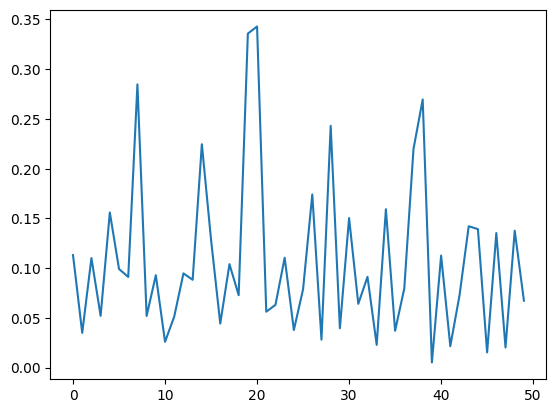

In [9]:
plt.plot(train_losses)
plt.show()

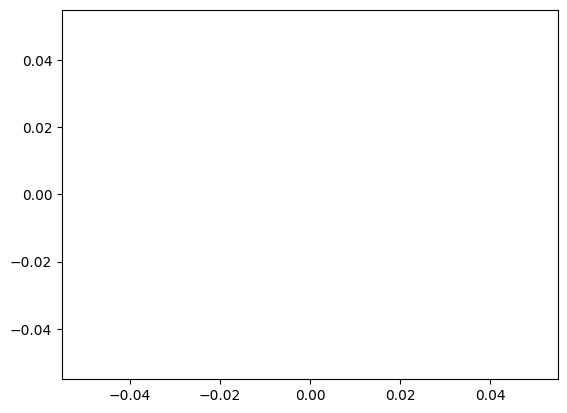

In [10]:
losses_sr = pd.Series(train_losses)
loss_mv = losses_sr.rolling(window=300).mean()
plt.plot(loss_mv)

### Construct Pipeline

In [11]:
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,
)
pipeline.to(device);

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/gayeon38/anaconda3/envs/vlm-env/lib/python3.8/site-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


In [ ]:
# # Test Generate Image
# lora_scale = 0.9
# pipeline_output = pipeline(
#     prompt=["a sky blue dress with a white belt and a white collar"],
#     num_inference_steps=20,
#     cross_attention_kwargs={"scale": lora_scale},
#     generator=torch.manual_seed(101)
# )
# pipeline_output.images[0]

### Save Fine-Tuned Model

In [12]:
# save model 
pipeline.save_pretrained(SAVE_MODEL_PATH)

# save model weights
unet_lora_state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
StableDiffusionPipeline.save_lora_weights(
    save_directory=SAVE_WEIGHTS_PATH,
    unet_lora_layers=unet_lora_state_dict,
    safe_serialization=True,
)

### Load Fine-Tuning Model
- LoRA Fine-Tuning 시 베이스 모델(Stable diffusion의 UNet)에 추가된 LoRA파라미터만 업데이트되고, 베이스 모델의 원본 가중치 저장X
- 저장된 pipeline에는 UNet의 기본 가중치X, LoRA델타만 포함됨
- 베이스 모델을 별도로 로드한 후 Fine-Tuning한 LoRA 가중치 적용

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/gayeon38/anaconda3/envs/vlm-env/lib/python3.8/site-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

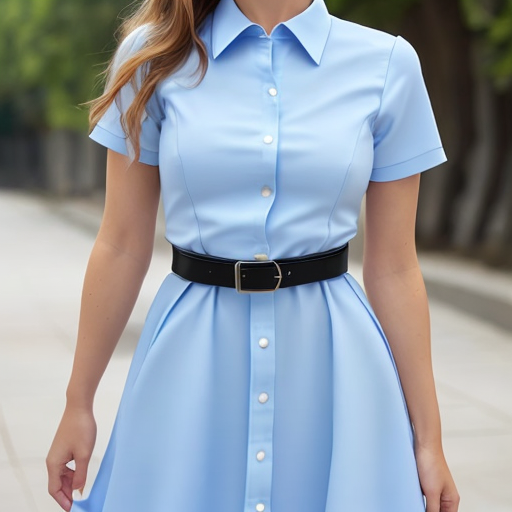

In [13]:
# 저장된 모델 불러오기
pipe = StableDiffusionPipeline.from_pretrained(PRE_TRAINED_MODEL_NAME, torch_dtype=torch.float16)
pipe.to("cuda")
pipe.load_lora_weights(SAVE_WEIGHTS_PATH, safe_serialization=True)

# prompt에 기반한 이미지 생성
prompt = "a sky blue dress with a white belt and a white collar"
generated_image = pipe(prompt).images[0]
generated_image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

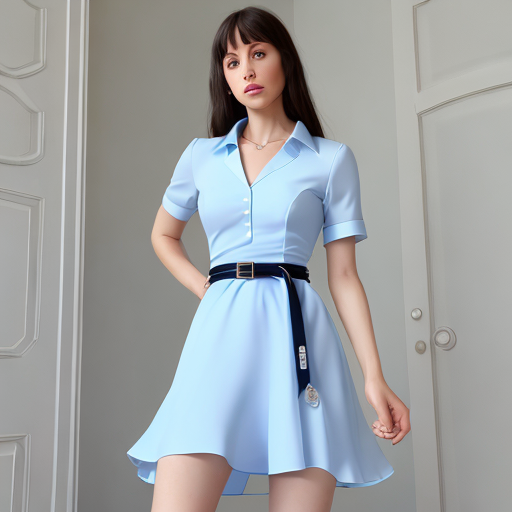

In [18]:
# 원본 모델
pipe = StableDiffusionPipeline.from_pretrained(PRE_TRAINED_MODEL_NAME, torch_dtype=torch.float16)
pipe.to("cuda")
# prompt에 기반한 이미지 생성
prompt = "a sky blue dress with a white belt and a white collar"
generated_image = pipe(prompt).images[0]
generated_image